In [ ]:


import os

DATA_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
SAVE_DIR = '/kaggle/working/'

os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_DIR}")
print(f"Data files: {os.listdir(DATA_DIR)}")

Data directory: /kaggle/input/competitions/aptos2019-blindness-detection
Output directory: /kaggle/working/
Data files: ['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


In [ ]:
!pip install timm

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import timm
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cpu


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/aptos2019-blindness-detection
/kaggle/input/competitions/aptos2019-blindness-detection/train_images
/kaggle/input/competitions/aptos2019-blindness-detection/test_images


In [4]:
df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["diagnosis"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["diagnosis"], random_state=42
)

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Total samples: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Train: 2929, Val: 366, Test: 367


In [5]:
def apply_clahe(pil_img):
    img = np.array(pil_img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl,a,b))
    img = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(img)

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms configured: 224x224 with conservative augmentation for CoAtNet")

Transforms configured: 224x224 with conservative augmentation for CoAtNet


In [7]:
class APTOSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]

        # FIXED: Use full Kaggle data path instead of relative path
        path = os.path.join(DATA_DIR, "train_images", f"{img_name}.png")
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 4 
train_loader = DataLoader(
    APTOSDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    APTOSDataset(val_df, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    APTOSDataset(test_df, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 183, Val batches: 23, Test batches: 23


In [ ]:


available_coatnet = [m for m in timm.list_models('coatnet*') if '224' in m]
print(f"Available CoAtNet 224 variants: {available_coatnet}")

preferred_model = "coatnet_nano_rw_224"
if preferred_model in timm.list_models('coatnet*'):
    model_name = preferred_model
else:
    all_coatnet = timm.list_models('coatnet*')
    coatnet_224 = [m for m in all_coatnet if '224' in m]
    if coatnet_224:
        for keyword in ['nano', 'pico', 'tiny', '0']:
            matches = [m for m in coatnet_224 if keyword in m]
            if matches:
                model_name = matches[0]
                break
        else:
            model_name = coatnet_224[0]
    else:
        model_name = all_coatnet[0] if all_coatnet else 'coatnet_0_rw_224'

print(f"\nUsing model: {model_name}")

model = timm.create_model(model_name, pretrained=True, num_classes=5).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Available CoAtNet 224 variants: ['coatnet_0_224', 'coatnet_0_rw_224', 'coatnet_1_224', 'coatnet_1_rw_224', 'coatnet_2_224', 'coatnet_2_rw_224', 'coatnet_3_224', 'coatnet_3_rw_224', 'coatnet_4_224', 'coatnet_5_224', 'coatnet_bn_0_rw_224', 'coatnet_nano_cc_224', 'coatnet_nano_rw_224', 'coatnet_pico_rw_224', 'coatnet_rmlp_0_rw_224', 'coatnet_rmlp_1_rw2_224', 'coatnet_rmlp_1_rw_224', 'coatnet_rmlp_2_rw_224', 'coatnet_rmlp_3_rw_224', 'coatnet_rmlp_nano_rw_224']

Using model: coatnet_nano_rw_224


model.safetensors:   0%|          | 0.00/60.6M [00:00<?, ?B/s]

Total params: 14,630,809
Trainable params: 14,630,809


In [10]:
class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["diagnosis"]),
    y=train_df["diagnosis"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822])


In [11]:
def freeze_backbone(model):
    """Freeze all layers except the classification head."""
    for name, param in model.named_parameters():
        if 'head' not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone frozen. Trainable params (head only): {trainable:,}")

def unfreeze_all(model):
    """Unfreeze all layers for fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"All layers unfrozen. Trainable params: {trainable:,}")

In [ ]:
def mixup_data(x, y, alpha=0.4):
    """Mixup augmentation to prevent overfitting."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Mixup loss calculation."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(model, train_loader, val_loader, total_epochs=20):

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    scaler = torch.cuda.amp.GradScaler()


    freeze_backbone(model)
    warmup_params = [p for p in model.parameters() if p.requires_grad]

    warmup_optimizer = torch.optim.Adam(warmup_params, lr=5e-4, weight_decay=5e-4)

    print("\n" + "="*60)
    print("STAGE 1: Warmup - Training classification head (1 epoch - OPTIMIZED)")
    print("="*60)

    for epoch in range(1):
        model.train()
        running_loss = 0
        loop = tqdm(train_loader, desc=f"Warmup Epoch {epoch+1}/1")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            warmup_optimizer.zero_grad()
            # ⚡ Mixed precision wrapper
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(warmup_params, max_norm=1.0)
            scaler.step(warmup_optimizer)
            scaler.update()
            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        print(f"  Warmup Epoch {epoch+1} avg loss: {running_loss/len(train_loader):.4f}")

    unfreeze_all(model)

 
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=5e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_epochs, eta_min=1e-7
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_qwk = 0
    patience = 5
    patience_counter = 0

    save_path = os.path.join(SAVE_DIR, 'coatnet_best.pth')

    print("\n" + "="*60)
    print(f"STAGE 2: Full Fine-tuning ({total_epochs} epochs, patience={patience})")
    print(f"OVERFITTING FIXES: weight_decay=5e-4, Mixup augmentation, reduced epochs")
    print(f"⚡ SPEED OPTIMIZATIONS: Mixed Precision (AMP), NUM_WORKERS=4, 1-epoch warmup")
    print("="*60 + "\n")

    for epoch in range(total_epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            
            with torch.cuda.amp.autocast():
                if np.random.rand() < 0.5:
                    images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.4)
                    outputs = model(images)
                    loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            _, preds_batch = torch.max(outputs, 1)
            correct += (preds_batch == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=correct/total)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss_sum, correct, total = 0, 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item()
                _, preds_batch = torch.max(outputs, 1)
                correct += (preds_batch == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(preds_batch.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_loss_sum / len(val_loader)
        val_acc = correct / total
        val_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{total_epochs} | LR: {current_lr:.2e}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val QWK: {val_qwk:.4f}")
        print(f"  Gap (Train-Val Acc): {(train_acc - val_acc):.4f}")
        print("-"*60)

        if val_qwk > best_val_qwk:
            best_val_qwk = val_qwk
            patience_counter = 0
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_qwk': val_qwk,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'model_name': model_name,
            }, save_path)
            file_size = os.path.getsize(save_path) / (1024 * 1024)  # Convert to MB
            print(f"  >>> Best model saved! Val QWK: {val_qwk:.4f}, Val Acc: {val_acc:.4f}")
            print(f"      Checkpoint: {save_path} ({file_size:.1f} MB)")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}!")
            break

    print(f"\nTraining complete. Best Val QWK: {best_val_qwk:.4f}")
    print(f"Best model saved to: {save_path}")
    
    if os.path.exists(save_path):
        file_size = os.path.getsize(save_path) / (1024 * 1024)
        print(f"✓ Confirmed: Model file exists ({file_size:.1f} MB)")
        print(f"✓ Location: /kaggle/working/coatnet_best.pth")
        print(f"✓ This will be available in Kaggle output files!")
    else:
        print(f"✗ WARNING: Model file not found at {save_path}")

    return train_losses, val_losses, train_accs, val_accs

In [13]:
history = train_model(model, train_loader, val_loader, total_epochs=20)

/tmp/ipykernel_17/1046094169.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


Backbone frozen. Trainable params (head only): 2,565

STAGE 1: Warmup - Training classification head (1 epoch - OPTIMIZED)


Warmup Epoch 1/1:   0%|          | 0/183 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_17/1046094169.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Warmup Epoch 1/1: 100%|██████████| 183/183 [08:45<00:00,  2.87s/it, loss=1.8]


  Warmup Epoch 1 avg loss: 1.6126
All layers unfrozen. Trainable params: 14,630,809

STAGE 2: Full Fine-tuning (20 epochs, patience=5)
OVERFITTING FIXES: weight_decay=5e-4, Mixup augmentation, reduced epochs
⚡ SPEED OPTIMIZATIONS: Mixed Precision (AMP), NUM_WORKERS=4, 1-epoch warmup



Epoch 1/20:   0%|          | 0/183 [00:00<?, ?it/s]/tmp/ipykernel_17/1046094169.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/20: 100%|██████████| 183/183 [16:13<00:00,  5.32s/it, acc=0.546, loss=1.4]


...


Epoch 14/20 | LR: 6.26e-06
  Train Loss: 1.1140 | Train Acc: 0.7312
  Val   Loss: 1.2495 | Val   Acc: 0.8224 | Val QWK: 0.8959
  Gap (Train-Val Acc): -0.0912
------------------------------------------------------------
  No improvement. Patience: 3/5


Epoch 15/20:   0%|          | 0/183 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_17/1046094169.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 15/20: 100%|██████████| 183/183 [15:38<00:00,  5.13s/it, acc=0.752, loss=0.718]



Epoch 15/20 | LR: 4.48e-06
  Train Loss: 1.0698 | Train Acc: 0.7524
  Val   Loss: 1.1972 | Val   Acc: 0.8306 | Val QWK: 0.8856
  Gap (Train-Val Acc): -0.0782
------------------------------------------------------------
  No improvement. Patience: 4/5


Epoch 16/20:   0%|          | 0/183 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_17/1046094169.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Epoch 16/20: 100%|██████████| 183/183 [15:36<00:00,  5.12s/it, acc=0.743, loss=1.68]



Epoch 16/20 | LR: 2.96e-06
  Train Loss: 1.0656 | Train Acc: 0.7428
  Val   Loss: 1.2338 | Val   Acc: 0.8197 | Val QWK: 0.8741
  Gap (Train-Val Acc): -0.0768
------------------------------------------------------------
  No improvement. Patience: 5/5

Early stopping triggered at epoch 16!

Training complete. Best Val QWK: 0.9073
Best model saved to: /kaggle/working/coatnet_best.pth
✓ Confirmed: Model file exists (167.8 MB)
✓ Location: /kaggle/working/coatnet_best.pth
✓ This will be available in Kaggle output files!


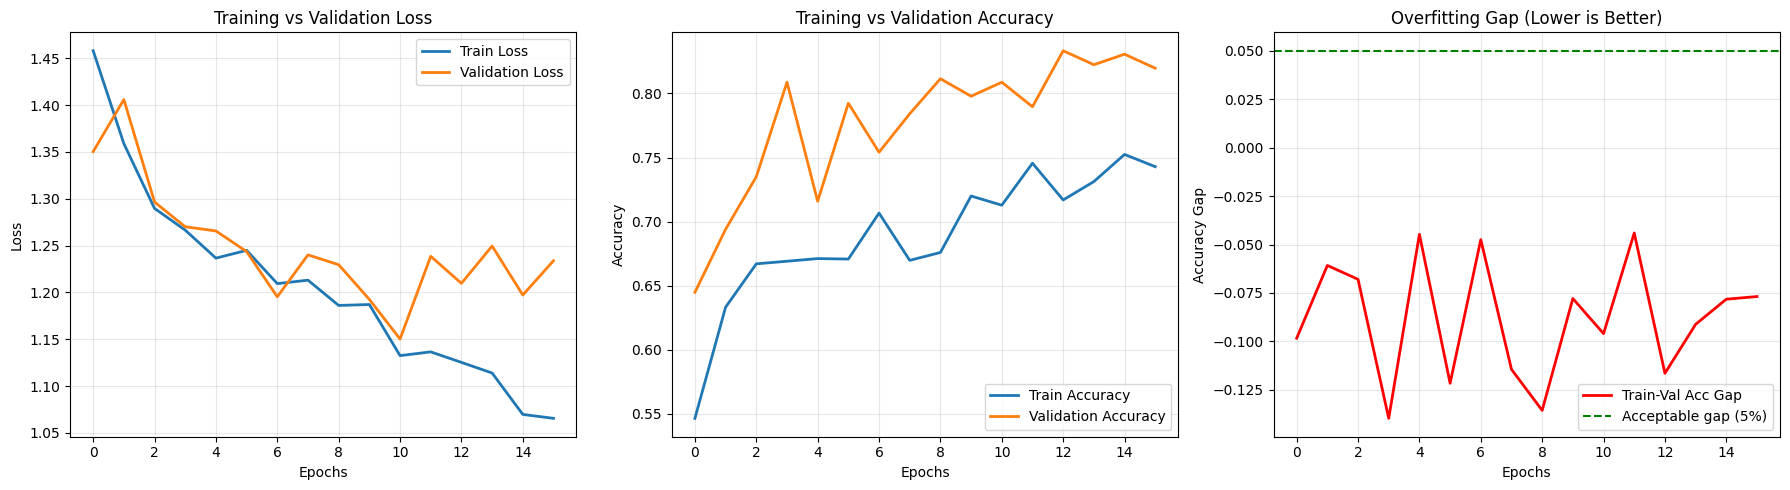

In [ ]:
def plot_history(history):
    train_losses, val_losses, train_accs, val_accs = history

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(train_losses, label="Train Loss", linewidth=2)
    axes[0].plot(val_losses, label="Validation Loss", linewidth=2)
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_accs, label="Train Accuracy", linewidth=2)
    axes[1].plot(val_accs, label="Validation Accuracy", linewidth=2)
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    gaps = [t - v for t, v in zip(train_accs, val_accs)]
    axes[2].plot(gaps, label="Train-Val Acc Gap", linewidth=2, color='red')
    axes[2].axhline(y=0.05, color='green', linestyle='--', label='Acceptable gap (5%)')
    axes[2].set_xlabel("Epochs")
    axes[2].set_ylabel("Accuracy Gap")
    axes[2].set_title("Overfitting Gap (Lower is Better)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
checkpoint = torch.load(os.path.join(SAVE_DIR, 'coatnet_best.pth'), map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Val Acc: {checkpoint['val_acc']:.4f}, Best Val QWK: {checkpoint['val_qwk']:.4f}")

model.eval()

preds, labels_all = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)

        preds.extend(outputs.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

print("\n" + "="*60)
print("TEST SET RESULTS - CoAtNet")
print("="*60)
print(classification_report(labels_all, preds,
      target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']))
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(labels_all, preds, weights='quadratic'):.4f}")
print(f"Test Accuracy: {np.mean(np.array(preds) == np.array(labels_all)):.4f}")

Loaded best model from epoch 11
Best Val Acc: 0.8087, Best Val QWK: 0.9073


Testing:   0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Testing: 100%|██████████| 23/23 [00:48<00:00,  2.13s/it]


TEST SET RESULTS - CoAtNet
               precision    recall  f1-score   support

        No DR       0.99      0.96      0.97       181
         Mild       0.64      0.57      0.60        37
     Moderate       0.77      0.68      0.72       100
       Severe       0.30      0.74      0.42        19
Proliferative       0.74      0.57      0.64        30

     accuracy                           0.80       367
    macro avg       0.69      0.70      0.67       367
 weighted avg       0.84      0.80      0.81       367

Quadratic Weighted Kappa: 0.9163
Test Accuracy: 0.8011


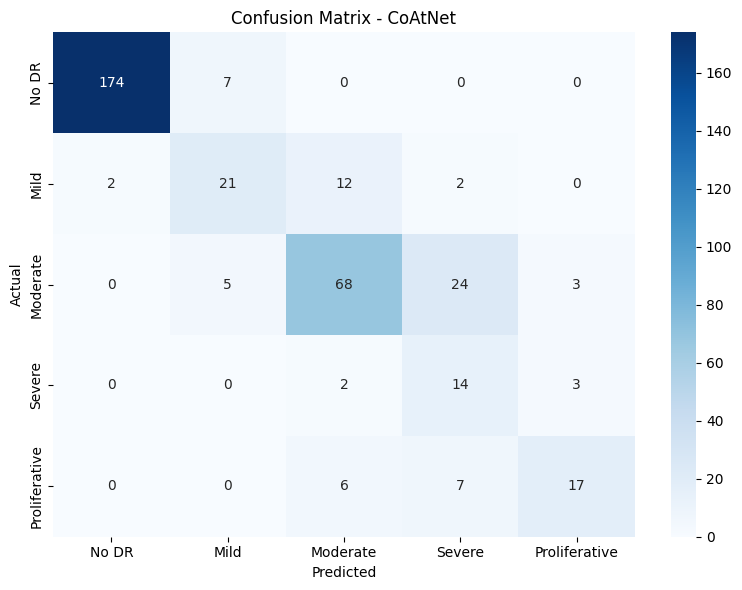

In [16]:
cm = confusion_matrix(labels_all, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
            yticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CoAtNet")
plt.tight_layout()
plt.show()

In [17]:
from IPython.display import FileLink

FileLink('/kaggle/working/coatnet_best.pth')

/kaggle/working/coatnet_best.pth